# Generated entirely by Claude - taking several iterations before it appeared to function well. Needs review.

# Plot intermediate QA flags

`flag_step2_generate-intermediate-qa-flags.ipynb` writes one intermediate flag store per `{gcm}_{var}_{scenario}_{ens}_{method}` leaf (tag), holding every individual flag in `srm.qa_flags.FLAG_LIST_TIME_VARYING` and `FLAG_LIST_TIME_INVARIANT`. `flag_step3_combine_and_write_to_source_coop.ipynb` then ORs those together into the two flags (`qa_flag_time_varying`, `qa_flag_time_invariant`) written to the production store.

This notebook plots each **individual intermediate flag** on its own -- before step 3 collapses them together -- so a flag that's only tripped for one scenario or ensemble member doesn't get lost in the combined flag. For every flag, it makes one figure per (variable, method) with panels arranged as ensemble member (rows) x scenario (columns), so all the leaves for that flag are visible side by side.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm.qa_flags import (
    FLAG_LIST_TIME_INVARIANT,
    FLAG_LIST_TIME_VARYING,
    INPUT_CHUNKS,
    discover_leaves,
    get_intermediate_flags,
    parse_tag,
)

# A. Define what data arrays exist to traverse

In [2]:
# --- Run parameters --------------------------------------------------------
# Keep these in sync with the parameters used to run flag_step2 / flag_step3 for the
# run(s) you want to inspect -- this notebook reads the same intermediate flag stores
# they wrote to/from, it doesn't touch the raw pipeline output.

VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

GCMS = ["CESM2-WACCM6", "UKESM1-1-LL"]

# Time-varying figures are slow to draw (one panel per ensemble member x scenario x
# source, stacked in blocks per flag), so they're saved here instead of rendered
# inline -- see Section D.
FIGURE_DIR = Path("./qa_flags_figures")
FIGURE_DIR.mkdir(exist_ok=True)

In [3]:
# Under v0.14.1, method (qdmsd/bcsd) is already a tier in the data tree and encoded in
# every tag's own suffix -- unlike the older setup this notebook was originally written
# for (bcsd v0.13.0 predating the method tier, living under a completely different
# branch/root_dir/prefix than qdmsd's pr-638-global branch), there's no separate
# location to discover per method anymore. Discovering once and reading each tag's own
# parsed `method` (see tag_info below) is both simpler and avoids a subtle bug: two
# *separate* discover_leaves calls pointed at the same identical location (one per old
# RUN_SOURCES key) each return the exact same full tag list -- including both real
# bcsd AND real qdmsd tags -- under both source labels, silently mixing the two
# methods together under whichever label happened to be looped over.
RUN_CONFIG = dict(
    branch="v0.14.1",
    root_dir="s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/",
    store_subset_id="global",
    bucket="carbonplan-srm",
    prefix="scratch/output/qa-intermediate-flags-v0.14.1",
)

# Preferred left-to-right order for scenario columns; anything discovered that isn't
# listed here is appended (sorted) after these.
SCENARIO_ORDER = ["historical", "ssp245", "g6_1p5k", "g6_1p5k_end"]

# Preferred top-to-bottom order for source (method) rows/columns.
SOURCE_ORDER = ["qdmsd", "bcsd"]

In [4]:
[_, tags, *_rest] = discover_leaves(
    gcms=GCMS,
    branch=RUN_CONFIG["branch"],
    root_dir=RUN_CONFIG["root_dir"],
    store_subset_id=RUN_CONFIG["store_subset_id"],
    is_downscaled=True,  # start with downscaled-only; debiased_coarse leaves excluded
)
print(f"{len(tags)} leaves")

/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


92 leaves


/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


# B. Index the intermediate flag store for every leaf

In [5]:
tag_info = pd.DataFrame(
    [
        {
            "tag": tag,
            "gcm": gcm,
            "variable": var,
            "scenario": scenario,
            "ensemble_member": ens,
            "method": method,
            "source": method,  # "source" == each tag's own parsed method; kept as a
            # separate column name only because Sections C/D below were written
            # against a "source" concept before v0.14.1 unified everything into one
            # tree/prefix -- it's not a second, independently-chosen grouping anymore.
        }
        for tag in tags
        for gcm, var, scenario, ens, method in [parse_tag(tag)]
    ]
)
tag_info = tag_info[tag_info["variable"].isin(VARIABLES)].reset_index(drop=True)
tag_info["key"] = list(zip(tag_info["source"], tag_info["tag"]))
tag_info.head()

,tag,gcm,variable,scenario,ensemble_member,method,source,key
0,CESM2-WACCM6_pr_g6_1p5k_002_bcsd,CESM2-WACCM6,pr,g6_1p5k,002,bcsd,bcsd,"(bcsd, CESM2-WACCM6_pr_g6_1p5k_002_bcsd)"
1,CESM2-WACCM6_pr_g6_1p5k_003_bcsd,CESM2-WACCM6,pr,g6_1p5k,003,bcsd,bcsd,"(bcsd, CESM2-WACCM6_pr_g6_1p5k_003_bcsd)"
2,CESM2-WACCM6_rsds_g6_1p5k_002_bcsd,CESM2-WACCM6,rsds,g6_1p5k,002,bcsd,bcsd,"(bcsd, CESM2-WACCM6_rsds_g6_1p5k_002_bcsd)"
3,CESM2-WACCM6_rsds_g6_1p5k_003_bcsd,CESM2-WACCM6,rsds,g6_1p5k,003,bcsd,bcsd,"(bcsd, CESM2-WACCM6_rsds_g6_1p5k_003_bcsd)"
4,CESM2-WACCM6_tas_g6_1p5k_002_bcsd,CESM2-WACCM6,tas,g6_1p5k,002,bcsd,bcsd,"(bcsd, CESM2-WACCM6_tas_g6_1p5k_002_bcsd)"


In [6]:
# Opening a zarr store is lazy/metadata-only, so this doesn't load any flag data yet --
# it just tells us which of FLAG_LIST_TIME_VARYING / FLAG_LIST_TIME_INVARIANT each leaf
# actually has written (a leaf can be missing a flag if e.g. its run_flag_loop cell in
# step2 hasn't been (re)run yet, or a flag like rsds_max_exceeded only ever applies to
# one variable).
#
# bcsd (v0.13.0) predates commit c431eac ("Change tags to work with new directory
# structure"), which changed a method-less leaf's tag from a bare
# "{gcm}_{var}_{scenario}_{ens}" to "..._no-method-specified". That legacy spelling
# doesn't apply under the current v0.14.1 tree (both bcsd and qdmsd are proper method
# tiers there, so every tag already ends in "_bcsd"/"_qdmsd"), but _open_flag_dataset
# still tries it as a fallback in case this notebook is ever pointed back at an older
# run -- it's a no-op for today's tags.
LEGACY_METHODLESS_SUFFIX = "_no-method-specified"


def _open_flag_dataset(tag, bucket, prefix):
    """Open `tag`'s store, and if it uses today's no-method-specified suffix, also try
    the pre-c431eac bare tag and merge the two -- current-tag variables win on overlap,
    the legacy store fills in anything only it has.

    Rechunks the result to INPUT_CHUNKS (the same shard-aligned layout discover_leaves
    uses for the raw data trees) before returning, instead of trusting xr.open_zarr's
    default chunk selection. The intermediate flag stores are written at a much
    smaller on-disk chunk size than that (see
    flag_step2_generate-intermediate-qa-flags.ipynb) -- without rechunking, a
    .mean(dim="time") over a long scenario like historical (~60,225 days) can expand
    into tens of thousands of individual small S3 GETs per leaf, which is slow purely
    from per-request network latency, not from any real compute or memory pressure
    (this is the exact problem detailed_analysis_intermediate_flags.ipynb's "Dask
    cluster" section documents and fixes the same way for its own flag reads)."""
    candidates = [tag]
    if tag.endswith(LEGACY_METHODLESS_SUFFIX):
        candidates.append(tag[: -len(LEGACY_METHODLESS_SUFFIX)])

    datasets = []
    for candidate in candidates:
        try:
            datasets.append(get_intermediate_flags(tag=candidate, bucket=bucket, prefix=prefix))
        except Exception:
            pass

    if not datasets:
        raise FileNotFoundError(f"no store found for any of {candidates}")

    merged_vars = {}
    for ds in reversed(datasets):  # candidates[0] (today's tag) applied last -> wins ties
        merged_vars.update(ds.data_vars)
    merged = xr.Dataset(merged_vars, coords=datasets[0].coords)
    rechunk = {dim: size for dim, size in INPUT_CHUNKS.items() if dim in merged.sizes}
    return merged.chunk(rechunk)


flag_datasets = {}
open_errors = []
for row in tag_info.itertuples():
    try:
        flag_datasets[row.key] = _open_flag_dataset(
            row.tag, bucket=RUN_CONFIG["bucket"], prefix=RUN_CONFIG["prefix"]
        )
    except Exception as exc:
        open_errors.append((row.source, row.tag, str(exc)))

tag_info = tag_info[tag_info["key"].isin(flag_datasets)].reset_index(drop=True)

if open_errors:
    print(f"{len(open_errors)} leaves failed to open (dropped):")
    for source, tag, err in open_errors[:20]:
        print(f"  [{source}] {tag}: {err}")
    if len(open_errors) > 20:
        print(f"  ... and {len(open_errors) - 20} more")

# Sanity check: confirms both sources actually made it into tag_info/flag_datasets. If
# a source is missing here, its leaves either weren't discovered in section A (check
# that cell's printed counts) or all failed to open above (check open_errors) -- either
# way, section D can't plot panels for a source that isn't in this count.
print(tag_info["source"].value_counts())

source
bcsd     46
qdmsd    46
Name: count, dtype: int64


In [7]:
# DIAGNOSTIC: compare what flag variables each source (method) actually has written.
# Section D only plots a source's leaf if `flag_name in flag_datasets[key].variables`,
# so if bcsd's variable names don't match FLAG_LIST_TIME_VARYING/FLAG_LIST_TIME_INVARIANT
# (e.g. an older flag_step2 used different names, or bcsd's store only has the two
# combined flags from flag_step3 rather than the individual intermediate ones), every
# bcsd leaf gets silently filtered out of every figure -- which would explain "no bcsd
# panel, ever" rather than just gaps.
sources_present = sorted(tag_info["source"].unique())
for source in sources_present:
    sample_key = next((k for k in flag_datasets if k[0] == source), None)
    if sample_key is None:
        print(f"{source}: no leaves opened")
        continue
    print(f"{source} sample ({sample_key[1]}):")
    print(f"  {sorted(flag_datasets[sample_key].data_vars)}")

print()
print("Flags this notebook is looking for:")
print(f"  time-varying:   {FLAG_LIST_TIME_VARYING}")
print(f"  time-invariant: {FLAG_LIST_TIME_INVARIANT}")

# Union across every leaf of a source (not just one sample), so we know whether the one
# sample above is representative or whether some bcsd leaves have more/fewer flags.
print()
for source in sources_present:
    union = set()
    for key, ds in flag_datasets.items():
        if key[0] == source:
            union |= set(ds.data_vars)
    print(
        f"{source}: union of flag variables across all {sum(1 for k in flag_datasets if k[0] == source)} leaves:"
    )
    print(f"  {sorted(union)}")

bcsd sample (CESM2-WACCM6_pr_g6_1p5k_002_bcsd):
  ['annual_outlier_flag', 'flipped_sign_g6_1p5k_g6_1p5k_end', 'flipped_sign_historical_g6_1p5k', 'flipped_sign_ssp245_g6_1p5k', 'outside_global_plausible_range', 'trend_distortion_g6_1p5k_g6_1p5k_end', 'trend_distortion_historical_g6_1p5k', 'trend_distortion_ssp245_g6_1p5k']
qdmsd sample (CESM2-WACCM6_pr_g6_1p5k_002_qdmsd):
  ['annual_outlier_flag', 'flipped_sign_g6_1p5k_g6_1p5k_end', 'flipped_sign_historical_g6_1p5k', 'flipped_sign_ssp245_g6_1p5k', 'outside_global_plausible_range', 'trend_distortion_g6_1p5k_g6_1p5k_end', 'trend_distortion_historical_g6_1p5k', 'trend_distortion_ssp245_g6_1p5k']

Flags this notebook is looking for:
  time-varying:   ['annual_outlier_flag', 'rsds_max_exceeded', 'outside_global_plausible_range', 'temperature_inconsistency']
  time-invariant: ['flipped_sign_ssp245_g6_1p5k', 'flipped_sign_historical_ssp245', 'flipped_sign_historical_g6_1p5k', 'trend_distortion_historical_ssp245', 'trend_distortion_ssp245_g6_1p

# C. Plotting helpers

In [8]:
ALL_FLAGS = FLAG_LIST_TIME_INVARIANT + FLAG_LIST_TIME_VARYING
TIME_VARYING_FLAGS = set(FLAG_LIST_TIME_VARYING)

# Shared color scheme for both figure types below (matches flag_step6's condensed
# summary figures): flat gray for confirmed-zero/unflagged pixels (distinct from a
# genuinely missing/unplotted one), red for flagged ones.
ZERO_COLOR = "0.7"
FLAGGED_COLOR = "red"
TIME_VARYING_CMAP = "Reds"

# Time-invariant flags are strictly 0/1 (no time-averaging), so give them a discrete
# 2-color map instead of a continuous gradient -- same gray/red scheme as the
# time-varying plots below, just without the gradient since there's only ever 0 or 1.
BINARY_CMAP = mcolors.ListedColormap([ZERO_COLOR, FLAGGED_COLOR])
BINARY_NORM = mcolors.BoundaryNorm([0, 0.5, 1], BINARY_CMAP.N)

FLAG_LABELS = {
    "annual_outlier_flag": "Annual Outlier",
    "rsds_max_exceeded": "RSDS Max Exceeded",
    "outside_global_plausible_range": "Outside Global Plausible Range",
    "temperature_inconsistency": "Temperature Inconsistency",
    "flipped_sign_historical_ssp245": "Flipped Sign (Historical − SSP2-4.5)",
    "flipped_sign_historical_g6_1p5k": "Flipped Sign (Historical − G6-1.5K)",
    "flipped_sign_ssp245_g6_1p5k": "Flipped Sign (SSP2-4.5 − G6-1.5K)",
    "flipped_sign_g6_1p5k_g6_1p5k_end": "Flipped Sign (G6-1.5K − G6-1.5K-end)",
    "trend_distortion_historical_ssp245": "Trend Distortion (Historical − SSP2-4.5)",
    "trend_distortion_historical_g6_1p5k": "Trend Distortion (Historical − G6-1.5K)",
    "trend_distortion_ssp245_g6_1p5k": "Trend Distortion (SSP2-4.5 − G6-1.5K)",
    "trend_distortion_g6_1p5k_g6_1p5k_end": "Trend Distortion (G6-1.5K − G6-1.5K-end)",
}

SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp245": "SSP2-4.5",
    "g6_1p5k": "G6-1.5K",
    "g6_1p5k_end": "G6-1.5K-end",
}


def _flag_label(flag_name):
    return FLAG_LABELS.get(flag_name, flag_name)


def _scenario_label(scenario):
    return SCENARIO_LABELS.get(scenario, scenario)


def _tighten(fig):
    """Shrink the padding a constrained-layout figure leaves by default -- otherwise
    these grids (especially the tall time-varying ones) end up with a lot of dead
    whitespace around and between panels."""
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01, wspace=0.02, hspace=0.03)


def _sorted_scenarios(scenarios):
    known = [s for s in SCENARIO_ORDER if s in scenarios]
    unknown = sorted(s for s in scenarios if s not in SCENARIO_ORDER)
    return known + unknown


def _sorted_sources(sources):
    known = [s for s in SOURCE_ORDER if s in sources]
    unknown = sorted(s for s in sources if s not in SOURCE_ORDER)
    return known + unknown


def _sorted_gcms(gcms):
    # GCMS (the run-parameters list, section A) sets the preferred left-to-right/
    # top-to-bottom order; anything discovered that isn't in it is appended (sorted).
    known = [g for g in GCMS if g in gcms]
    unknown = sorted(g for g in gcms if g not in GCMS)
    return known + unknown


def _candidate_names(flag_name):
    """Variable-name spellings to try for a canonical flag name. Some existing qdmsd
    leaves have flipped_sign_* written without the underscore right after "sign" (e.g.
    "flipped_signg6_1p5k_g6_1p5k_end" instead of "flipped_sign_g6_1p5k_g6_1p5k_end") --
    an older flag_step2 built the name that way before it was fixed to match
    FLAG_LIST_TIME_INVARIANT. Accept both spellings here rather than silently treating
    every leaf written under the old spelling as if it had no flag at all."""
    candidates = [flag_name]
    if flag_name.startswith("flipped_sign_"):
        candidates.append("flipped_sign" + flag_name[len("flipped_sign_") :])
    return candidates


def _resolve_flag_name(ds, flag_name):
    """The actual variable name in `ds` for `flag_name`, trying each candidate
    spelling in turn, or None if none of them are present."""
    for candidate in _candidate_names(flag_name):
        if candidate in ds.variables:
            return candidate
    return None


def lazy_flag_map(source, tag, flag_name):
    """Still-lazy (lat, lon) DataArray for one tag/flag -- same selection/reduction as
    load_flag_map, just without the .load() at the end. Build a batch of these across
    every leaf/flag a figure needs, then hand the whole batch to one dask.compute()
    call (see plot_variable_time_varying/plot_variable_time_invariant below) -- calling
    .load() one at a time in a loop, as this used to do, forces every leaf's S3
    read + reduction to happen strictly one after another, using only one dask task
    at a time no matter how many workers are idle. Batching lets the scheduler run
    them all concurrently instead, which is where nearly all of this notebook's
    runtime was going.
    """
    ds = flag_datasets[(source, tag)]
    da = ds[_resolve_flag_name(ds, flag_name)]
    if flag_name in TIME_VARYING_FLAGS:
        da = da.mean(dim="time")
    return da


def load_flag_map(source, tag, flag_name):
    """Eager (already-computed) version of lazy_flag_map, for one-off lookups outside
    the batched figure-building code (e.g. ad hoc exploration in a scratch cell)."""
    return lazy_flag_map(source, tag, flag_name).load()

In [9]:
def plot_variable_time_varying(variable, var_df):
    """Saves one figure per (variable, flag_name) time-varying flag that has at least
    one leaf for this variable -- rather than stacking every flag into one combined
    figure. With up to 4 time-varying flags x dozens of (gcm, ensemble member) rows,
    one combined figure became a 150+-panel grid where every panel collapsed to zero
    size (matplotlib even warns "constrained_layout not applied because axes sizes
    collapsed to zero") and was unreadable at any preview/thumbnail scale. One figure
    per flag keeps each figure's row count down to just that flag's own (gcm,
    ensemble member) rows, so panels are actually legible.

    Each figure's rows are (gcm, ensemble member) pairs -- gcm is folded into the row
    key (not a separate column axis) since ensemble-member labels are already
    gcm-specific strings (e.g. CESM's "002" vs UKESM's "r2i1p1f2"), so this just makes
    that GCM explicit in the row label. Columns are every (scenario, source) pair
    present for that flag, so a qdmsd panel still sits directly next to its bcsd
    counterpart.

    Every leaf/flag combo needed across ALL of this variable's flags is still built as
    a lazy_flag_map and computed together in a single dask.compute() call up front --
    only the number of *figures* produced from that one batch changed, not how the
    data is fetched; see lazy_flag_map's docstring for why the batching matters.

    Each figure is saved to `FIGURE_DIR` as `time_varying_{variable}_{flag_name}.png`
    instead of rendered inline -- see Section D.
    """
    unit = "cell-days"

    # Pass 1 (cheap, metadata-only): figure out which (flag_name, key) combos exist at
    # all, building the lazy arrays but not computing anything yet.
    pending_keys = []  # (flag_name, (gcm, ens, scenario, source))
    pending_arrays = []  # lazy DataArray, same order as pending_keys
    for flag_name in FLAG_LIST_TIME_VARYING:
        for row in var_df.itertuples():
            if _resolve_flag_name(flag_datasets[row.key], flag_name) is None:
                continue
            key = (row.gcm, row.ensemble_member, row.scenario, row.source)
            pending_keys.append((flag_name, key))
            pending_arrays.append(lazy_flag_map(row.source, row.tag, flag_name))

    if not pending_arrays:
        print(f"--- {variable}: no time-varying flags found, skipping ---")
        return

    # Pass 2 (the actual I/O + reduction): one batched compute for every leaf/flag
    # combo this variable needs, instead of one .load() per combo.
    computed_arrays = dask.compute(*pending_arrays)
    computed = dict(zip(pending_keys, computed_arrays, strict=True))

    blocks = []  # (flag_name, sorted (gcm, ens), {(gcm, ens, scenario, source): map})
    for flag_name in FLAG_LIST_TIME_VARYING:
        maps = {key: arr for (fname, key), arr in computed.items() if fname == flag_name}
        if not maps:
            continue
        gcm_ens_present = {(k[0], k[1]) for k in maps}
        gcm_rank = {g: i for i, g in enumerate(_sorted_gcms({ge[0] for ge in gcm_ens_present}))}
        gcm_ens_pairs = sorted(gcm_ens_present, key=lambda ge: (gcm_rank[ge[0]], ge[1]))
        blocks.append((flag_name, gcm_ens_pairs, maps))

    if not blocks:
        print(f"--- {variable}: no time-varying flags found, skipping ---")
        return

    for flag_name, gcm_ens_pairs, maps in blocks:
        col_pairs = {(k[2], k[3]) for k in maps}
        scenarios = _sorted_scenarios({p[0] for p in col_pairs})
        sources = _sorted_sources({p[1] for p in col_pairs})
        col_keys = [(s, src) for s in scenarios for src in sources if (s, src) in col_pairs]

        nrows, ncols = len(gcm_ens_pairs), len(col_keys)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(2.6 * ncols, 2.0 * nrows),
            subplot_kw={"projection": ccrs.PlateCarree()},
            squeeze=False,
            layout="constrained",
        )
        _tighten(fig)
        fig.suptitle(f"{_flag_label(flag_name)} — {variable}", fontsize=12)

        nonzero = [m for m in maps.values() if float(np.nansum(m > 0)) > 0]
        vmax = max((float(np.nanmax(m.where(m > 0))) for m in nonzero), default=1)

        block_mappable = None
        for i, (gcm, ens) in enumerate(gcm_ens_pairs):
            for j, (scenario, source) in enumerate(col_keys):
                ax = axes[i, j]
                if i == 0:
                    ax.set_title(f"{_scenario_label(scenario)}\n{source}", fontsize=9)
                if j == 0:
                    ax.text(
                        -0.25,
                        0.5,
                        f"{gcm}/{ens}",
                        transform=ax.transAxes,
                        rotation=90,
                        rotation_mode="anchor",
                        ha="center",
                        va="center",
                        fontsize=8,
                    )

                ax.set_xticks([])
                ax.set_yticks([])
                ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="black")

                key = (gcm, ens, scenario, source)
                if key not in maps:
                    ax.text(
                        0.5,
                        0.5,
                        "n/a",
                        transform=ax.transAxes,
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="0.6",
                    )
                    continue

                m = maps[key]
                n_flagged = float(np.nansum(m > 0))
                # Flat gray for confirmed-zero pixels, plotted *underneath* the red
                # layer below -- without this, a confirmed-zero pixel and a genuinely
                # missing/NaN one both render as blank background and are impossible
                # to tell apart.
                zero_mask = m.notnull() & (m == 0)
                xr.where(zero_mask, 1, np.nan).plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap=mcolors.ListedColormap([ZERO_COLOR]),
                    vmin=0,
                    vmax=1,
                    add_colorbar=False,
                    add_labels=False,
                )

                # add_labels=False stops xarray's .plot() from calling its own
                # ax.set_title(...), which otherwise silently overwrites the
                # scenario/source title set above.
                if n_flagged > 0:
                    block_mappable = m.where(m > 0).plot(
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        cmap=TIME_VARYING_CMAP,
                        vmin=0,
                        vmax=vmax,
                        add_colorbar=False,
                        add_labels=False,
                    )

                ax.annotate(
                    f"{n_flagged:,.0f} {unit}",
                    xy=(0.5, -0.05),
                    xycoords="axes fraction",
                    ha="center",
                    fontsize=7,
                )

        if block_mappable is not None:
            fig.colorbar(
                block_mappable,
                ax=axes,
                orientation="horizontal",
                location="top",
                shrink=0.5,
                aspect=40,
                pad=0.02,
                label="mean frac. days flagged",
            )

        out_path = FIGURE_DIR / f"time_varying_{variable}_{flag_name}.png"
        fig.savefig(out_path, dpi=150)
        plt.close(fig)
        print(f"saved -> {out_path}")

In [10]:
def plot_variable_time_invariant(variable, var_df):
    """One figure for `variable`: one row per time-invariant flag that has at least
    one leaf for this variable (row order follows FLAG_LIST_TIME_INVARIANT), one
    column per (gcm, source) pair -- so every trend_distortion_*/flipped_sign_* check
    for this variable is visible in a single figure, with every gcm/method combo side
    by side for direct comparison. GCM must be its own column (not folded into
    "source"/method) since different GCMs produce genuinely different flag maps --
    without it, a cell that happened to span multiple GCMs would silently show only
    one of them with no indication of which.

    Each (flag, gcm, source) map is computed once per (gcm, variable, scenario-pair)
    from the ensemble mean and written identically to every leaf on both sides of that
    comparison *within a single gcm/source* (see flag_step2_generate-intermediate-qa-
    flags.ipynb, section C), so there's only one representative map to plot per cell
    here -- this re-checks the "identical within a gcm/source" assumption before
    plotting each one, which means reading every leaf in a (flag, gcm, source) group,
    not just one -- all of them are built as lazy_flag_map and computed together in
    one dask.compute() call below, rather than one .load() per leaf.
    """
    # Pass 1 (cheap, metadata-only): every (flag_name, gcm, source) group's member
    # tags, deferring the actual reads.
    groups = {}  # (flag_name, gcm, source) -> list of tags
    for flag_name in FLAG_LIST_TIME_INVARIANT:
        for gcm in _sorted_gcms(var_df["gcm"].unique()):
            gcm_df = var_df[var_df["gcm"] == gcm]
            for source in _sorted_sources(gcm_df["source"].unique()):
                source_df = gcm_df[gcm_df["source"] == source]
                tags_with_flag = [
                    row.tag
                    for row in source_df.itertuples()
                    if _resolve_flag_name(flag_datasets[(source, row.tag)], flag_name) is not None
                ]
                if tags_with_flag:
                    groups[(flag_name, gcm, source)] = tags_with_flag

    if not groups:
        print(f"--- {variable}: no time-invariant flags found, skipping ---")
        return

    pending_keys = []  # (flag_name, gcm, source, tag)
    pending_arrays = []
    for (flag_name, gcm, source), group_tags in groups.items():
        for tag in group_tags:
            pending_keys.append((flag_name, gcm, source, tag))
            pending_arrays.append(lazy_flag_map(source, tag, flag_name))

    # Pass 2 (the actual I/O): one batched compute for every leaf this figure needs
    # across every flag/gcm/source group, instead of one .load() per leaf.
    computed_arrays = dask.compute(*pending_arrays)
    computed = {k: v for k, v in zip(pending_keys, computed_arrays, strict=True)}

    rows = []  # (flag_name, {(gcm, source): (map, n_leaves)})
    cols_present = set()
    for (flag_name, gcm, source), group_tags in groups.items():
        maps = [computed[(flag_name, gcm, source, tag)] for tag in group_tags]
        mismatched = [tag for tag, m in zip(group_tags, maps) if not m.equals(maps[0])]
        if mismatched:
            print(
                f"WARNING: {flag_name} / {variable} / {gcm} / {source} is NOT identical across all its leaves as expected -- differs for: {mismatched}"
            )
        cols_present.add((gcm, source))

    for flag_name in FLAG_LIST_TIME_INVARIANT:
        per_col = {
            (gcm, source): (computed[(flag_name, gcm, source, group_tags[0])], len(group_tags))
            for (fname, gcm, source), group_tags in groups.items()
            if fname == flag_name
        }
        if per_col:
            rows.append((flag_name, per_col))

    cols = [
        (gcm, source)
        for gcm in _sorted_gcms({c[0] for c in cols_present})
        for source in _sorted_sources({c[1] for c in cols_present})
        if (gcm, source) in cols_present
    ]
    nrows, ncols = len(rows), len(cols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.4 * ncols, 2.4 * nrows),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
        layout="constrained",
    )
    _tighten(fig)
    fig.suptitle(f"time-invariant flags — {variable}", fontsize=11)

    mappable = None
    for i, (flag_name, per_col) in enumerate(rows):
        for j, (gcm, source) in enumerate(cols):
            ax = axes[i, j]
            ax.set_xticks([])
            ax.set_yticks([])
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
            if i == 0:
                ax.set_title(f"{gcm}\n{source}", fontsize=9)
            if j == 0:
                ax.text(
                    -0.2,
                    0.5,
                    _flag_label(flag_name),
                    transform=ax.transAxes,
                    rotation=90,
                    rotation_mode="anchor",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

            if (gcm, source) not in per_col:
                ax.text(
                    0.5,
                    0.5,
                    "n/a",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="0.6",
                )
                continue

            m, n_leaves = per_col[(gcm, source)]
            n_flagged = float(np.nansum(m > 0))
            mappable = m.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=BINARY_CMAP,
                norm=BINARY_NORM,
                add_colorbar=False,
                add_labels=False,
            )
            ax.annotate(
                f"{n_flagged:,.0f} cells ({n_leaves} leaves)",
                xy=(0.5, -0.05),
                xycoords="axes fraction",
                ha="center",
                fontsize=7,
            )

    if mappable is not None:
        cbar = fig.colorbar(
            mappable,
            ax=axes,
            orientation="horizontal",
            location="top",
            shrink=0.4,
            aspect=30,
            pad=0.02,
            ticks=[0.25, 0.75],
        )
        cbar.ax.set_xticklabels(["0", "1"])
        cbar.set_label("flagged")

    plt.show()
    plt.close(fig)

# D. Plot every variable

Loops over every variable (in VARIABLES order). For each one, makes two figures:

- `plot_variable_time_varying`: every time-varying flag that has at least one leaf for this variable, stacked as row-blocks (one block per flag, ensemble members within a block), columns are every (scenario, source) pair present -- so qdmsd and bcsd sit side by side, and all of a variable's time-varying checks are visible in one figure instead of one figure per check.
- `plot_variable_time_invariant`: every time-invariant flag that has at least one leaf for this variable, one row per flag, one column per source -- same idea, one figure per variable instead of one per (flag, variable).

A flag that only applies to some variables (e.g. `rsds_max_exceeded`, or a `trend_distortion_*` that only covers two scenarios) simply contributes fewer rows/blocks to that variable's figure, or none at all if it doesn't apply.

In [11]:
present_variables = [v for v in VARIABLES if v in tag_info["variable"].unique()]

=== tas (20 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      7
              qdmsd     7
UKESM1-1-LL   bcsd      3
              qdmsd     3


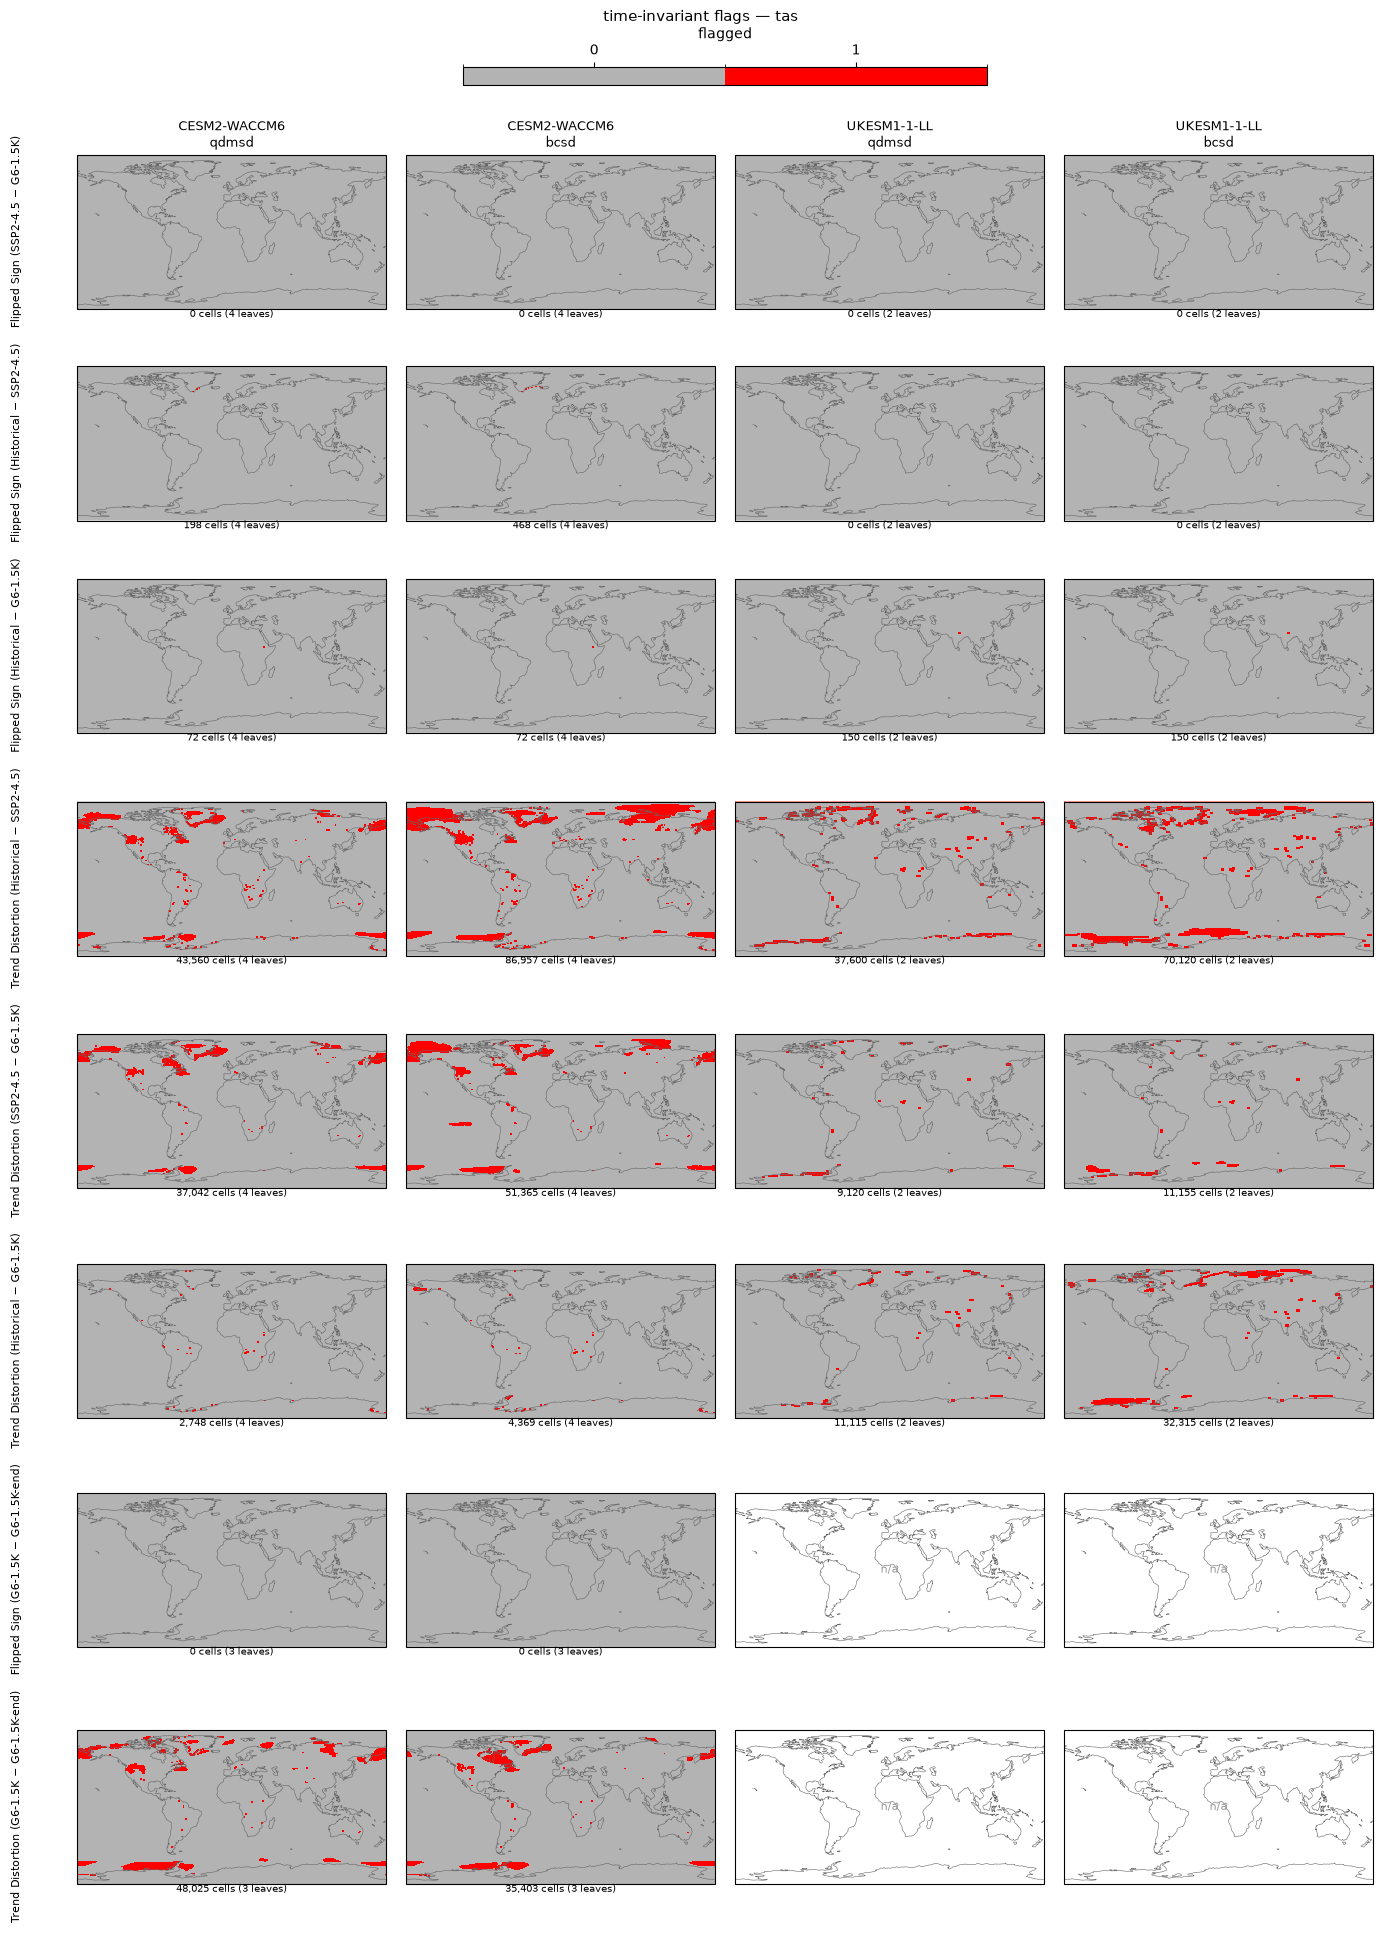

=== tasmax (16 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      5
              qdmsd     5
UKESM1-1-LL   bcsd      3
              qdmsd     3


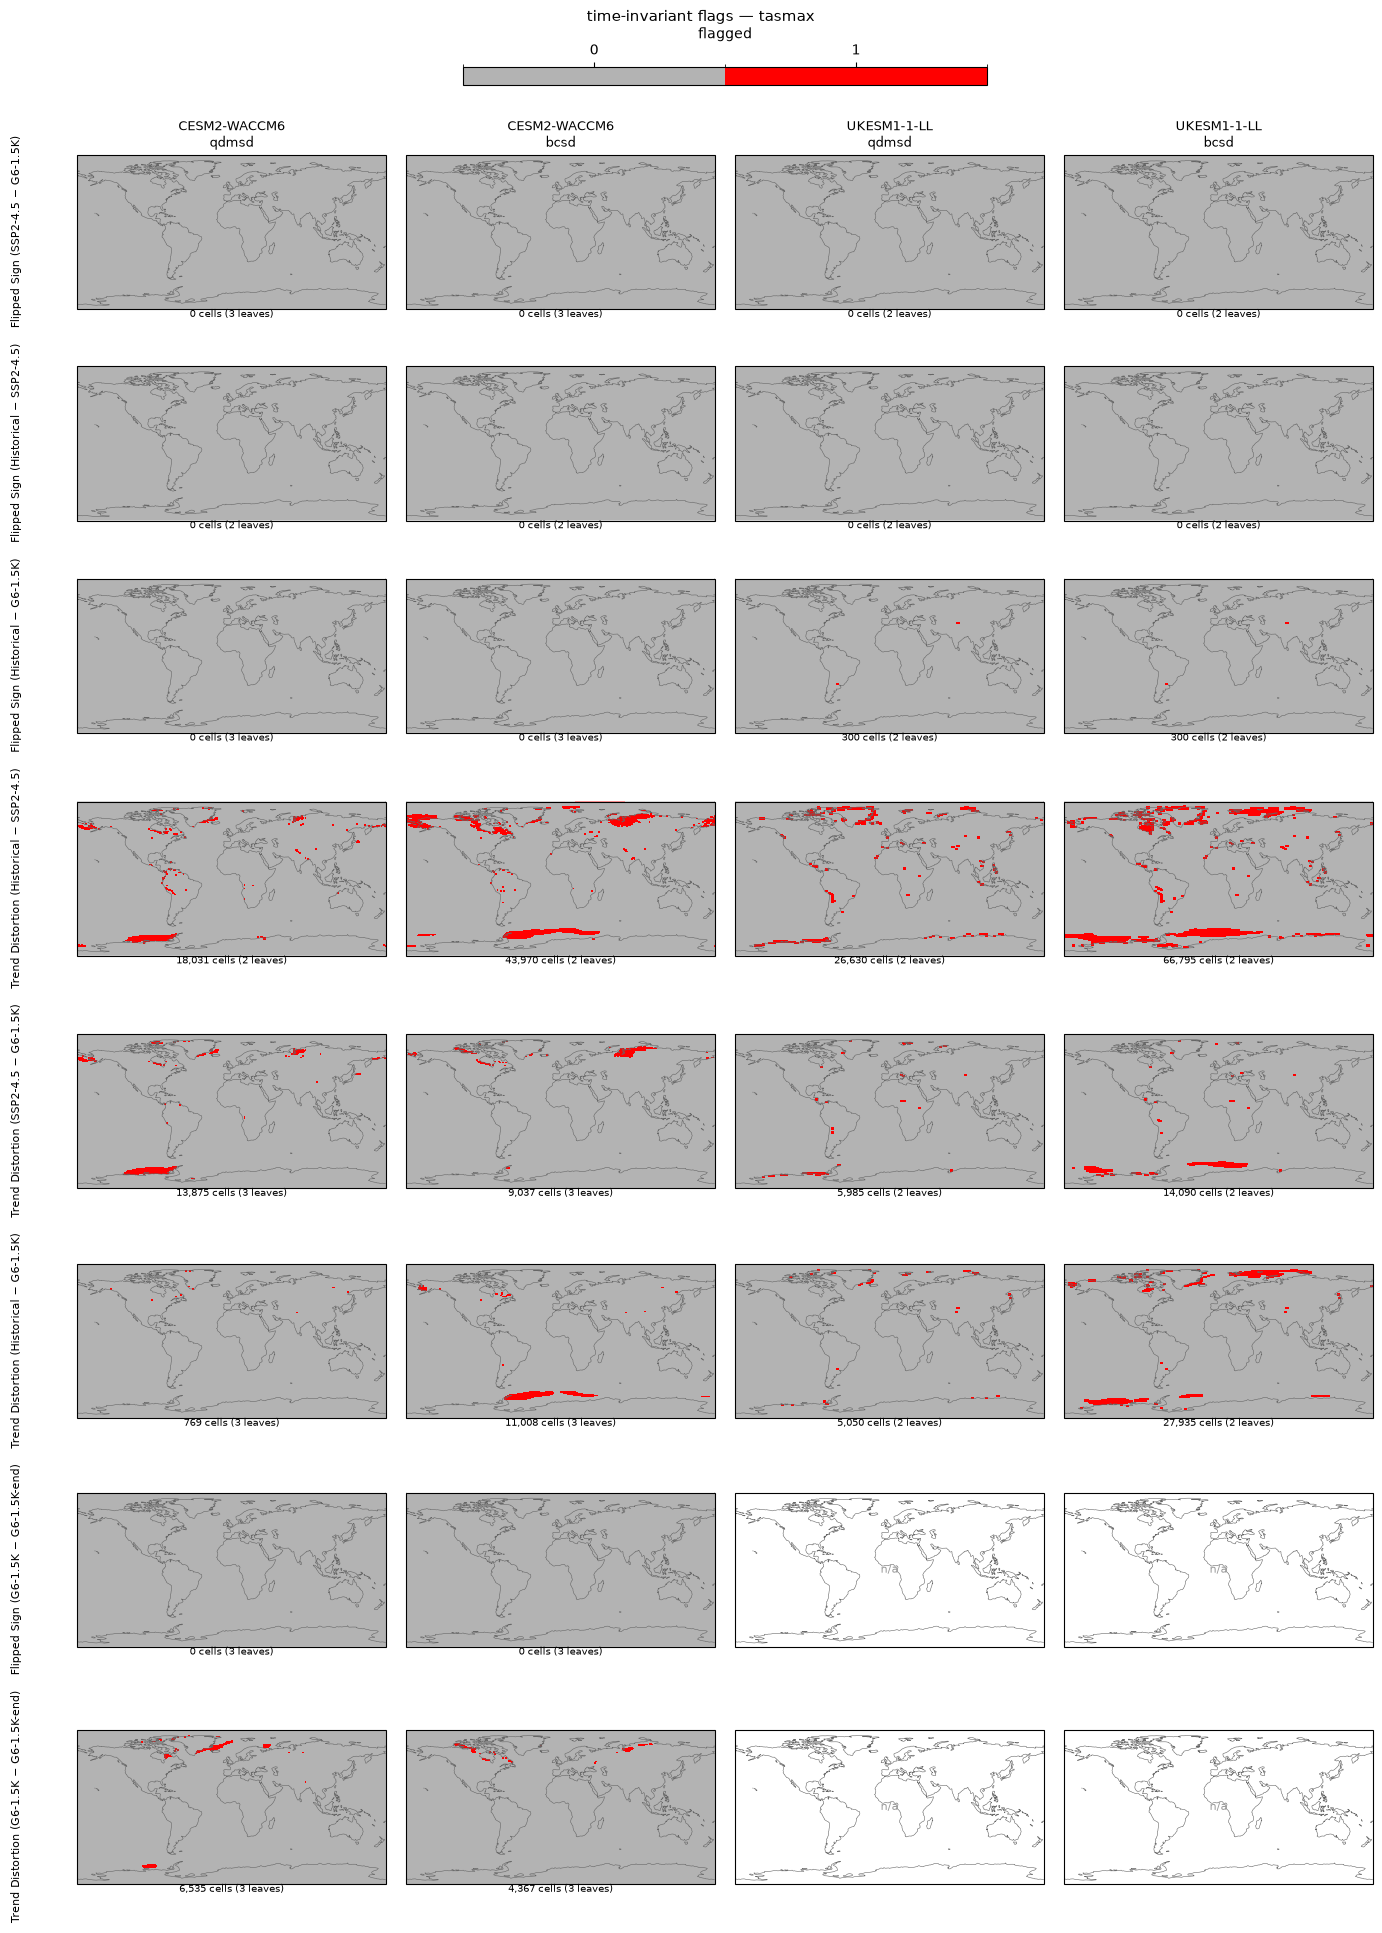

=== tasmin (16 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      5
              qdmsd     5
UKESM1-1-LL   bcsd      3
              qdmsd     3


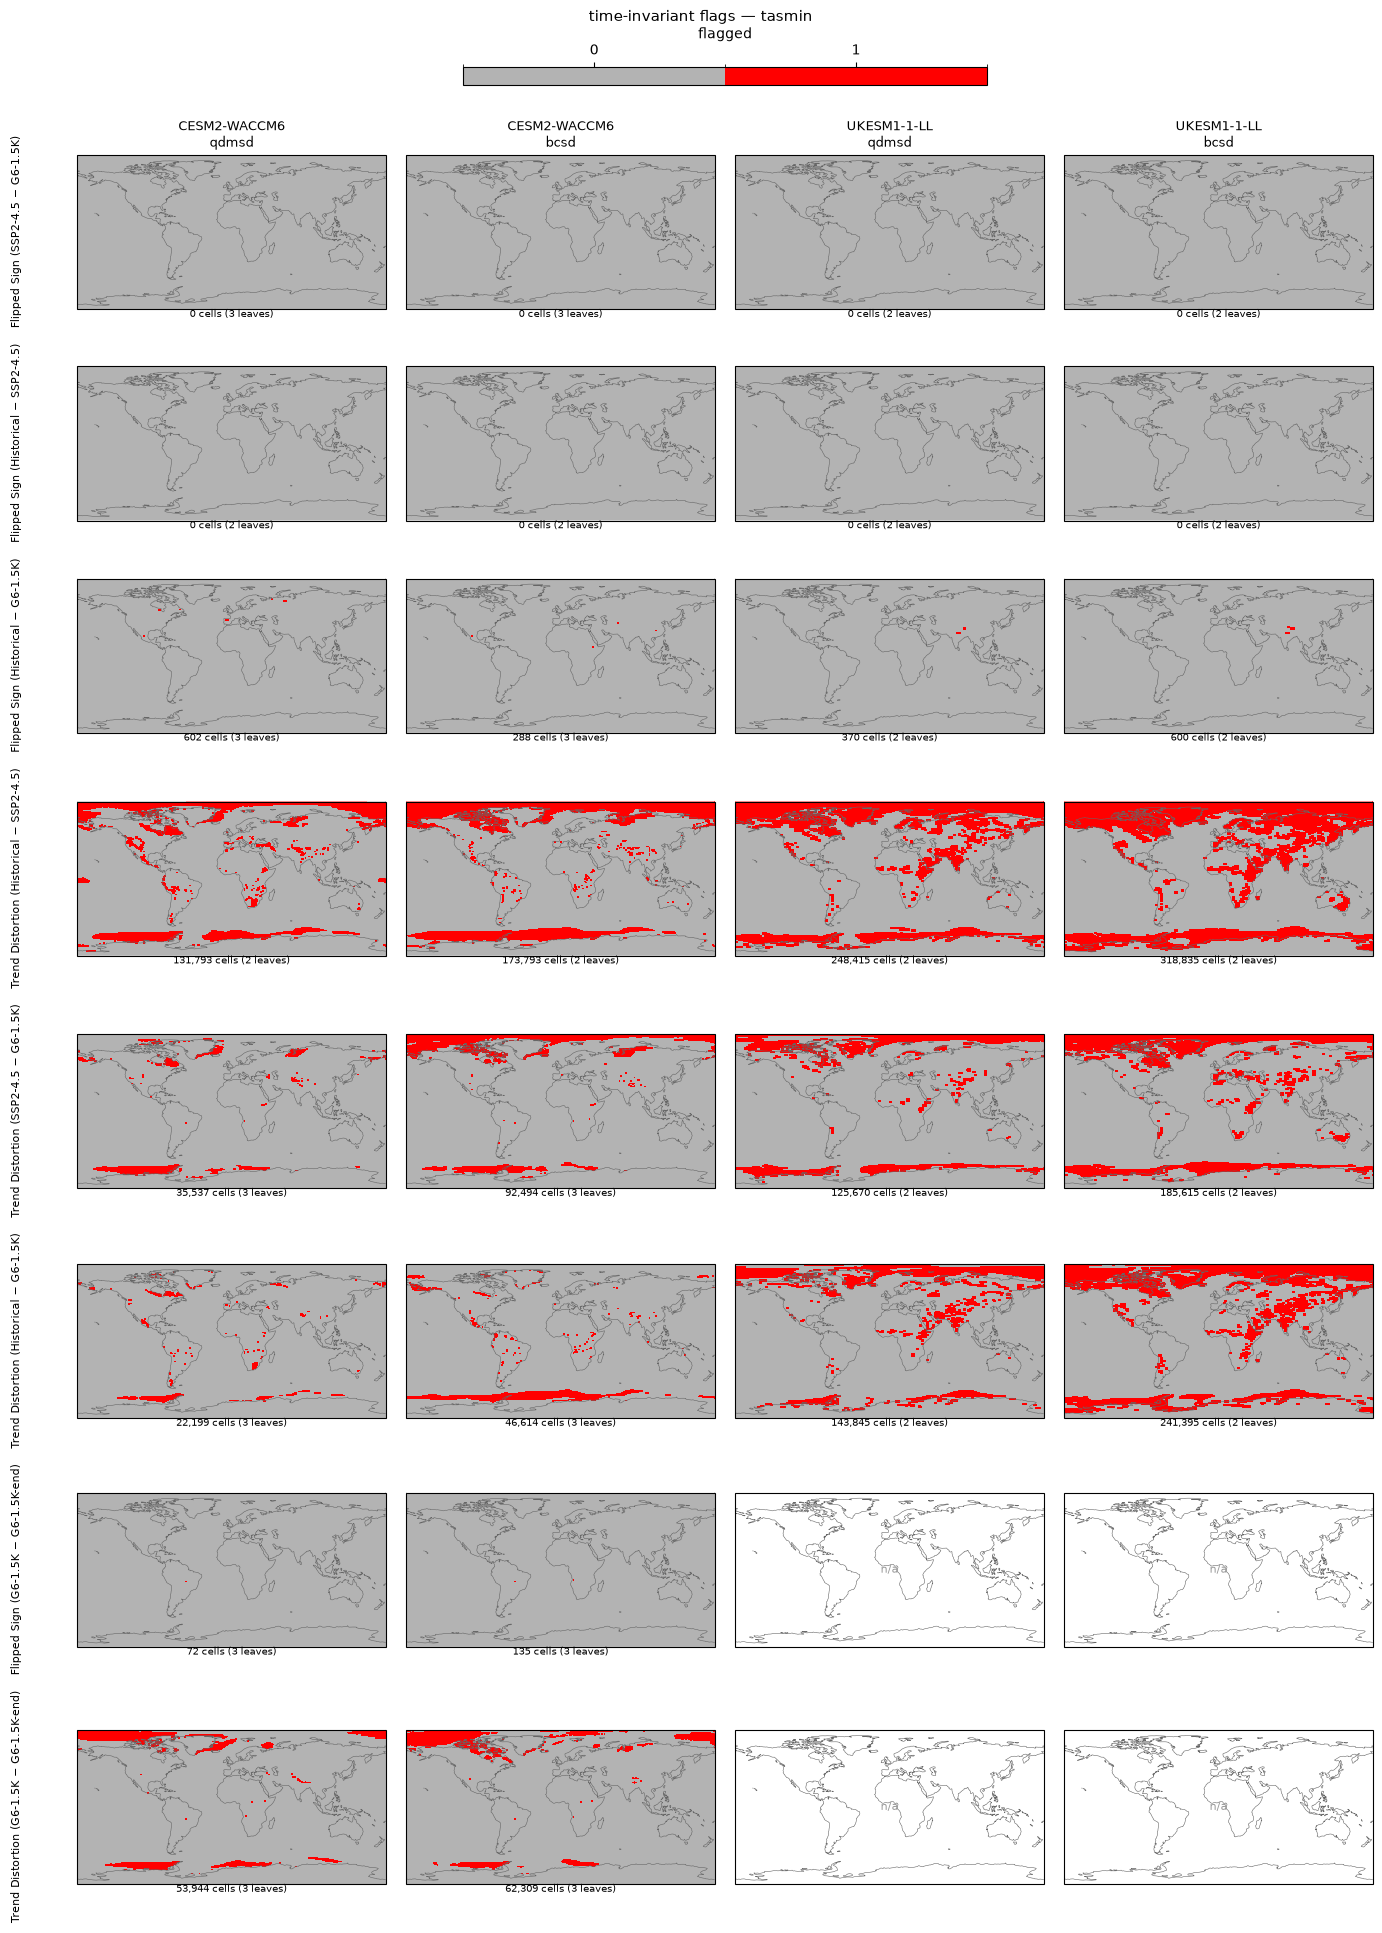

=== pr (20 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      7
              qdmsd     7
UKESM1-1-LL   bcsd      3
              qdmsd     3


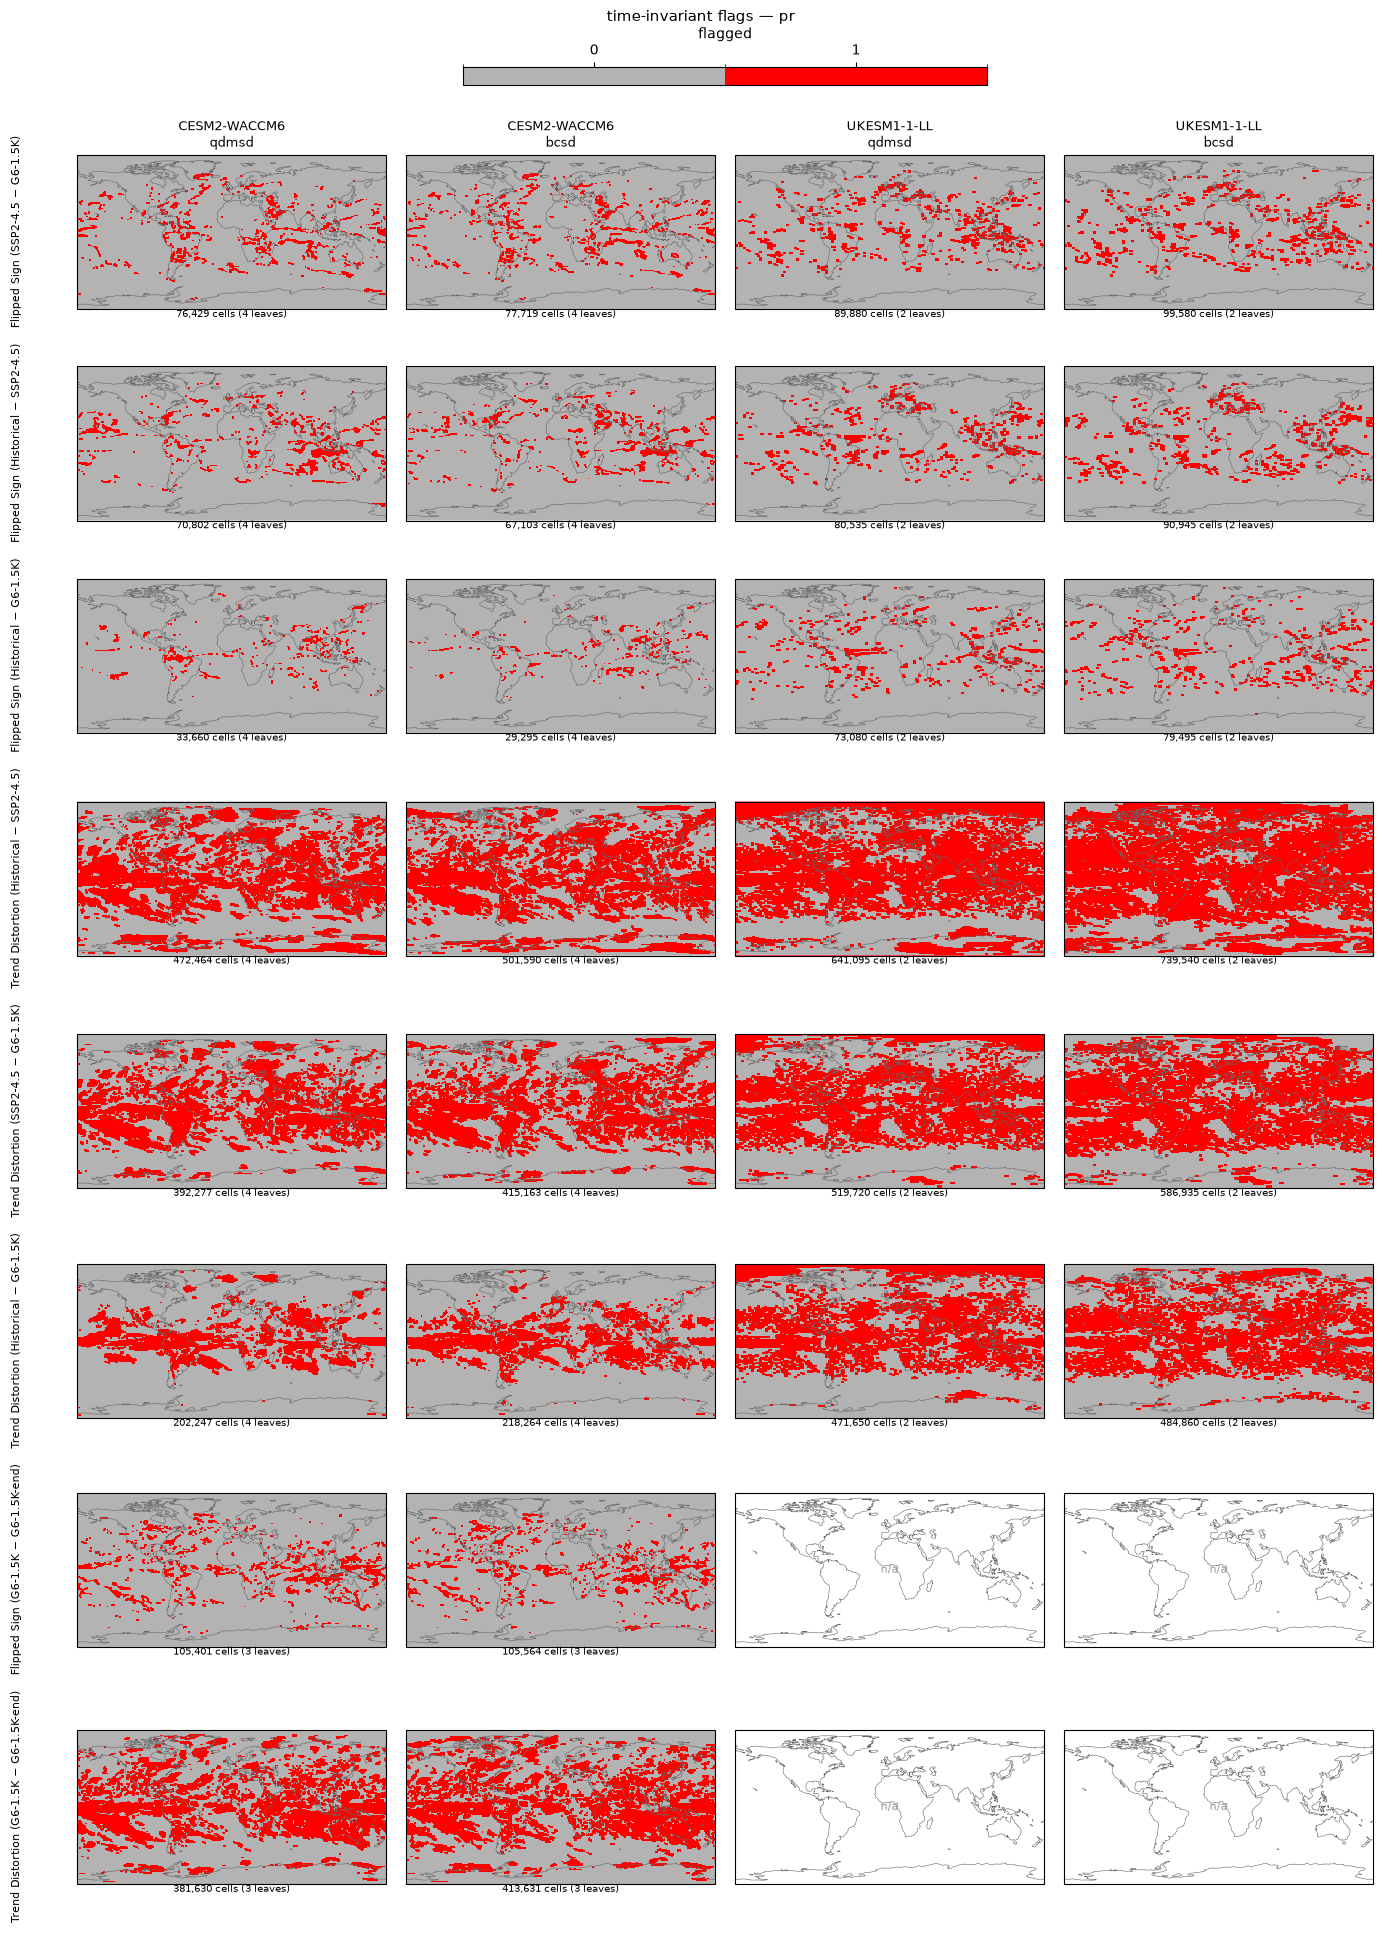

=== rsds (20 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      7
              qdmsd     7
UKESM1-1-LL   bcsd      3
              qdmsd     3


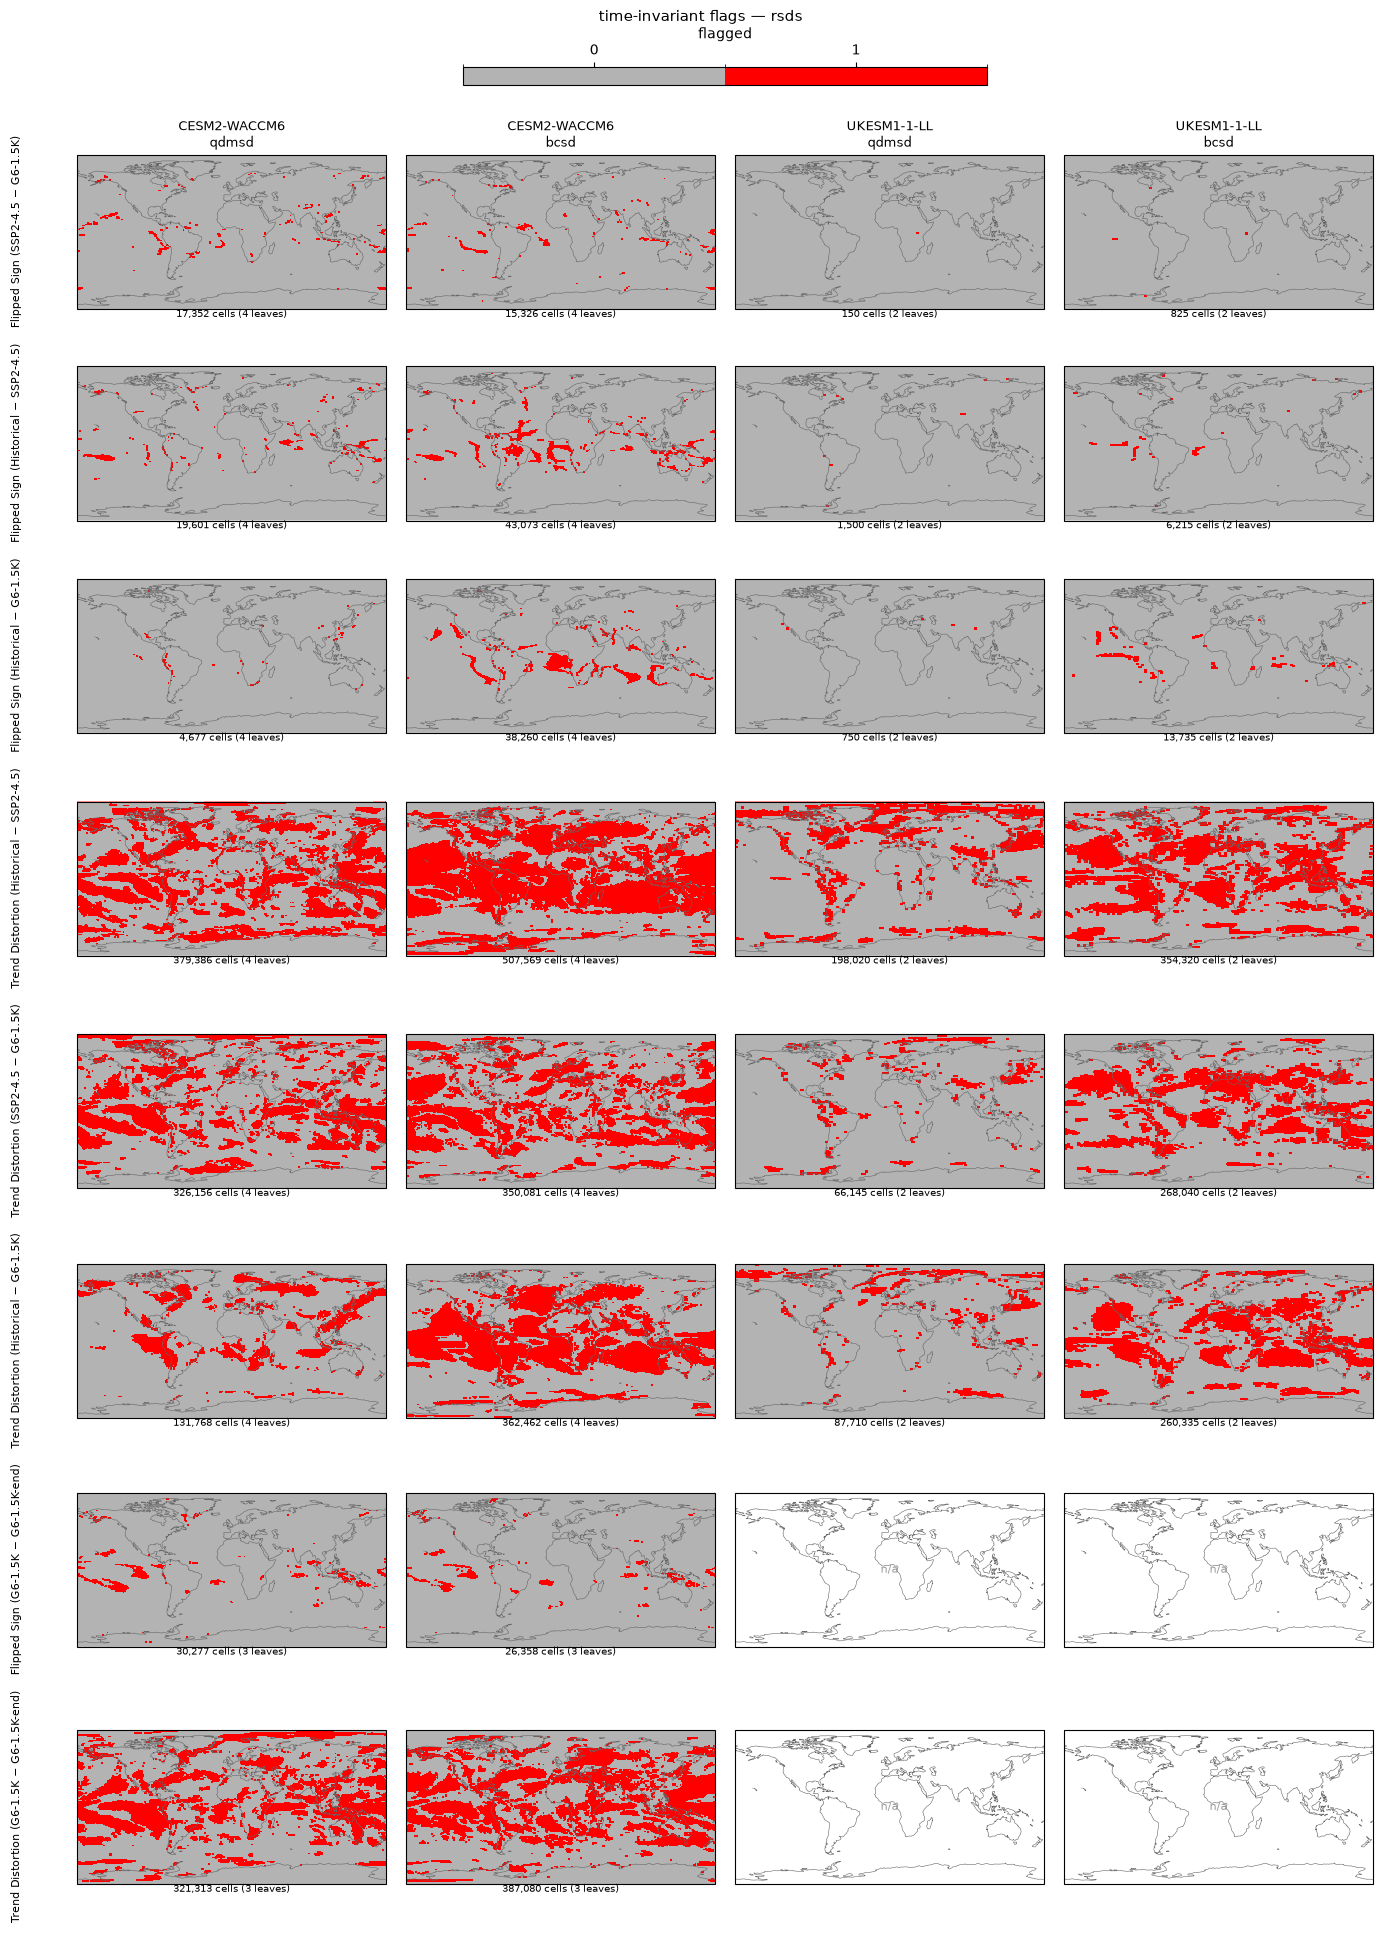

In [14]:
for variable in present_variables:
    var_df = tag_info[tag_info["variable"] == variable]
    print(f"=== {variable} ({len(var_df)} leaves) ===")
    print(var_df.groupby(["gcm", "source"]).size().rename("n_leaves").to_string())
    plot_variable_time_invariant(variable, var_df)

## Time-varying flags (separate cell -- slow, saved to disk)

Kept in its own cell rather than merged into the loop above: it's much slower to draw
(one panel per ensemble member x scenario x source, for every flag), and re-running it
shouldn't clear the time-invariant figures already rendered above. Figures are saved as
PNGs to `FIGURE_DIR` (`./qa_flags_figures/`) instead of being displayed inline -- open
them there rather than waiting on this cell.

In [12]:
for variable in present_variables:
    var_df = tag_info[tag_info["variable"] == variable]
    print(f"=== {variable} ({len(var_df)} leaves) ===")
    print(var_df.groupby(["gcm", "source"]).size().rename("n_leaves").to_string())
    plot_variable_time_varying(variable, var_df)

=== tas (20 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      7
              qdmsd     7
UKESM1-1-LL   bcsd      3
              qdmsd     3


/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


saved -> qa_flags_figures/time_varying_tas_annual_outlier_flag.png
saved -> qa_flags_figures/time_varying_tas_outside_global_plausible_range.png
saved -> qa_flags_figures/time_varying_tas_temperature_inconsistency.png
=== tasmax (16 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      5
              qdmsd     5
UKESM1-1-LL   bcsd      3
              qdmsd     3
saved -> qa_flags_figures/time_varying_tasmax_annual_outlier_flag.png
saved -> qa_flags_figures/time_varying_tasmax_outside_global_plausible_range.png
saved -> qa_flags_figures/time_varying_tasmax_temperature_inconsistency.png
=== tasmin (16 leaves) ===
gcm           source
CESM2-WACCM6  bcsd      5
              qdmsd     5
UKESM1-1-LL   bcsd      3
              qdmsd     3
saved -> qa_flags_figures/time_varying_tasmin_annual_outlier_flag.png
saved -> qa_flags_figures/time_varying_tasmin_outside_global_plausible_range.png
saved -> qa_flags_figures/time_varying_tasmin_temperature_inconsistency.png
=== pr (20 leaves) ===
g